<a href="https://colab.research.google.com/github/AnshuSingh000/ucc-bench-simulator-benchmarking-tutorial/blob/main/benchmark_simulators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Benchmarking?

Imagine five car companies claim that their cars are fast, reliable, and fuel-efficient.

🚗 Car A

🚗 Car B

🚗 Car C

🚗 Car D

🚗 Car E

How would we determine which one performs better?

We would not test one car on a smooth highway, another on a mountain road, and a third in city traffic. That would be unfair.

Instead, we would create the same test for every car:

* The same route
* The same distance
* The same weather conditions
* The same starting fuel level

Only then can we compare their performance fairly.

This process is called **benchmarking**.

Benchmarking means evaluating different systems using the same task and measuring their performance.

In quantum computing, we can do something similar.

Instead of comparing cars, we compare quantum simulators.

Instead of driving the same road, we run the same quantum circuit.

Instead of measuring fuel consumption or travel time, we measure things such as execution time and how performance changes as problems become larger.

You may encounter unfamiliar terms such as *quantum simulator*, *quantum circuit*, *qubit*, or *circuit depth*. Don't worry about understanding them yet. We will build each idea from the ground up as we move through the tutorial.

Before we can compare different simulators, however, we need to answer a more fundamental question:

**What exactly is a quantum simulator, and why do we need one in the first place?**


# What is a Quantum Simulator?

Most people do not have a quantum computer sitting on their desk.

In fact, real quantum computers are among the most advanced machines ever built. They require specialized hardware, carefully controlled environments, and are often accessed through cloud services rather than owned directly.

So how do students, researchers, and developers learn quantum computing without having a quantum computer?

The answer is simple:

**They use quantum simulators.**

A quantum simulator is a program that runs on a classical computer but imitates the behavior of a quantum computer.

Instead of using real qubits, the simulator uses mathematical models to predict how those qubits would behave.

This allows us to:

* Learn quantum computing concepts
* Test quantum circuits
* Develop and debug algorithms
* Perform experiments before using real quantum hardware

Think of it like a flight simulator.

Before flying a real aircraft, pilots spend many hours practicing in simulators. These simulators allow them to learn, make mistakes, and build confidence without the cost and risk of operating a real plane.

Quantum simulators serve a similar purpose. They provide a safe and accessible environment where we can explore quantum computing using ordinary computers.

In this tutorial, we will compare several quantum simulators and observe how they perform when asked to solve exactly the same problem.

But before we can compare simulators, we need to understand the basics.


# Before We Build: The Words We Will Use

Before we start writing code, let us pause and understand the main words that will appear throughout this tutorial.

You may already know some of them. If not, treat this section as a quick first introduction. The goal is not to memorize every definition perfectly, but to become comfortable enough to follow the experiment.

| Term                | Simple meaning                                                                                                                                 |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| **Quantum circuit** | A set of instructions given to a quantum computer or simulator.                                                                                |
| **Qubit**           | The basic unit of quantum information. It is like a bit, but it can represent more than just 0 or 1 before measurement.                        |
| **Quantum gate**    | An operation applied to a qubit, similar to an instruction in a program.                                                                       |
| **Measurement**     | The step where we read the final result from a qubit.                                                                                          |
| **Simulator**       | A classical computer program that imitates how a quantum computer would behave.                                                                |
| **Benchmarking**    | Testing different systems using the same task so their performance can be compared fairly.                                                     |
| **Execution time**  | How long a simulator takes to run a circuit.                                                                                                   |
| **Circuit depth**   | How many layers of operations a circuit has. A deeper circuit usually means more work for the simulator.                                       |
| **Scalability**     | How performance changes when the problem becomes larger. For example, what happens when we increase the number of qubits or the circuit depth? |

These definitions are intentionally simple. We will return to them again as we build the benchmark step by step.

Now let us see what a quantum circuit looks like.


In [8]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 3 qubits and 3 classical bits
demo_circuit = QuantumCircuit(3, 3)

# Apply a Hadamard gate to qubit 0
# This creates a superposition state
demo_circuit.h(0)

# Apply a Controlled-NOT gate between qubit 0 and qubit 1
demo_circuit.cx(0, 1)

# Apply a rotation gate to qubit 2
demo_circuit.rx(0.5, 2)

# Apply another Controlled-NOT gate
demo_circuit.cx(1, 2)

# Measure all qubits and store the results
demo_circuit.measure([0, 1, 2], [0, 1, 2])

# Display the circuit
print(demo_circuit)

# No need to decode every gate yet. We're just getting acquainted.


        ┌───┐             ┌─┐      
q_0: ───┤ H ├─────■───────┤M├──────
        └───┘   ┌─┴─┐     └╥┘┌─┐   
q_1: ───────────┤ X ├──■───╫─┤M├───
     ┌─────────┐└───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ┤ Rx(0.5) ├─────┤ X ├─╫──╫─┤M├
     └─────────┘     └───┘ ║  ║ └╥┘
c: 3/══════════════════════╩══╩══╩═
                           0  1  2 


# What is a Quantum Circuit?

The image above shows a small quantum circuit.

At first glance, it may look like lines, boxes, and symbols. That is normal. Quantum circuits can look unfamiliar when you see them for the first time.

A simple way to understand it is this:

**A quantum circuit is a recipe for a quantum computer.**

The horizontal lines represent qubits.

The symbols placed on those lines represent quantum gates.

The final measurement symbols (M) show where we read the output.

The circuit is read from left to right, just like a timeline.

```text
Start → Apply gates → Measure → Get result
```

In this tutorial, we will not try to learn every possible quantum gate. Instead, we will use circuits as test objects.

Our main question is:

**If the same circuit is given to different simulators, how long does each simulator take to run it?**

That is the benchmarking experiment we are going to build.


# Why Do Different Simulators Exist?

At this point, a reasonable question is:

**If all simulators are trying to imitate a quantum computer, why do we need more than one?**

The answer is that different simulators are designed with different goals in mind.

Some simulators prioritize speed.

Some prioritize accuracy.

Some are designed for education and ease of use.

Others are optimized for large-scale research problems.

This is similar to vehicles.

A sports car, a truck, and a family sedan can all travel from one city to another, but they are designed for different purposes and may perform very differently under the same conditions.

Quantum simulators work in a similar way.

Even when given the same quantum circuit, different simulators may require different amounts of time and computational resources to complete the task.

This raises an interesting question:

**How can we compare them fairly?**

To answer that question, we need to design a benchmark.


# Our Benchmarking Experiment

In this tutorial, we will compare multiple quantum simulators using the same quantum circuit.

To keep the comparison fair:

* Every simulator will receive the same circuit.
* Every simulator will run on the same machine.
* We will measure the execution time for each run.
* We will gradually increase the size of the problem.

Specifically, we will investigate two factors:

### Number of Qubits

The number of qubits determines the size of the quantum system being simulated.

### Circuit Depth

Circuit depth describes how many layers of operations are applied to the qubits.

As these values increase, the simulation generally becomes more challenging.

Our goal is not to find the "best" simulator.

Instead, we want to understand how different simulators behave as the problem grows.

Now that we understand the experiment, let's build the quantum circuit that every simulator will be asked to run.


In [11]:
from qiskit import QuantumCircuit

# Function to generate a benchmark circuit
# We can change the number of qubits and circuit depth
# without rewriting the circuit every time.
def generate_circuit(num_qubits, depth):

    # Create a quantum circuit with the desired number of qubits
    qc = QuantumCircuit(num_qubits)

    # Repeat the same pattern of operations 'depth' times
    for _ in range(depth):

        # Apply single-qubit gates to every qubit
        for q in range(num_qubits):

            # Hadamard gate creates superposition
            qc.h(q)

            # Rotation around the X-axis
            qc.rx(0.5, q)

            # Rotation around the Z-axis
            qc.rz(0.3, q)

        # Create interactions between neighbouring qubits
        # using Controlled-NOT (CNOT) gates
        for q in range(num_qubits - 1):

            qc.cx(q, q + 1)

    # Return the completed circuit
    return qc


# Generate a circuit with:
# 10 qubits
# depth = 5
circuit = generate_circuit(10, 5)

# Display the circuit
print(circuit)

     ┌───┐┌─────────┐┌─────────┐     ┌───┐┌─────────┐┌─────────┐           »
q_0: ┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├──■──┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├───────────»
     ├───┤├─────────┤├─────────┤┌─┴─┐└───┘└──┬───┬──┘├─────────┤┌─────────┐»
q_1: ┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├┤ X ├──■─────┤ H ├───┤ Rx(0.5) ├┤ Rz(0.3) ├»
     ├───┤├─────────┤├─────────┤└───┘┌─┴─┐   └───┘   └──┬───┬──┘├─────────┤»
q_2: ┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├─────┤ X ├─────■────────┤ H ├───┤ Rx(0.5) ├»
     ├───┤├─────────┤├─────────┤     └───┘   ┌─┴─┐      └───┘   └──┬───┬──┘»
q_3: ┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├─────────────┤ X ├────────■────────┤ H ├───»
     ├───┤├─────────┤├─────────┤             └───┘      ┌─┴─┐      └───┘   »
q_4: ┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├────────────────────────┤ X ├────────■─────»
     ├───┤├─────────┤├─────────┤                        └───┘      ┌─┴─┐   »
q_5: ┤ H ├┤ Rx(0.5) ├┤ Rz(0.3) ├───────────────────────────────────┤ X ├───»
     ├───┤├─────────┤├─────────┤                                   └───┘   »

### What did we just build?

Let's not worry about the exact meaning of every gate yet.

The important idea is that we created a circuit whose size can be controlled using two variables:

- `num_qubits` controls how many qubits the circuit contains.
- `depth` controls how many layers of operations are applied.

These two values will be the main variables in our benchmark.

Later, we will increase both of them and observe how the execution time changes across different simulators.

# Measuring Performance

Now that we have a circuit, we need a way to measure how long a simulator takes to run it.

A benchmark is not just about running a program—it is about collecting data.

For this tutorial, we will use **execution time** as our primary metric.

Execution time simply tells us how long a simulator needs to complete a task.

To measure this, we will:

1. Start a timer.
2. Run the circuit.
3. Stop the timer.
4. Record the result.

We will repeat this process for every simulator using exactly the same circuit.

Let's begin with our first simulator.


# Simulator 1: Qiskit Aer

In [12]:
from qiskit_aer import AerSimulator
import time

# Create the simulator
simulator = AerSimulator()

# Start timer
start_time = time.perf_counter()

# Run the circuit
result = simulator.run(circuit).result()

# Stop timer
end_time = time.perf_counter()

# Calculate execution time
execution_time = end_time - start_time

print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 0.022377 seconds


### Our First Benchmark Result

The simulator completed the task in approximately **0.022 seconds**.

That sounds fast, but by itself the number does not tell us much.

Imagine a student finishing a test in 10 minutes.

Is that impressive?

The answer depends on the difficulty of the test.

Similarly, a simulator taking 0.022 seconds is neither good nor bad on its own. The number only becomes meaningful when we compare it against:

* Other simulators
* Larger circuits
* Greater numbers of qubits
* Greater circuit depths

Benchmarking is not about collecting one number.

It is about collecting many measurements and looking for patterns.


# Automating the Benchmark

Running one experiment manually is easy.

Running fifty experiments manually is not.

Since we want to compare multiple simulators, qubit counts, and circuit depths, we need a way to automate the process.

The idea is simple:

1. Create a circuit.
2. Run the simulator.
3. Measure the execution time.
4. Save the result.
5. Repeat.

Instead of recording everything by hand, we will store our results in a table.


In [14]:
import pandas as pd
results = []

results.append({
    "Simulator": "Qiskit Aer",
    "Qubits": 10,
    "Depth": 5,
    "Execution Time (s)": execution_time
})

pd.DataFrame(results)

,Simulator,Qubits,Depth,Execution Time (s)
0,Qiskit Aer,10,5,0.022377


# Simulator 2: Cirq

Now we will run the same benchmark idea using Cirq.

Cirq is another quantum computing framework. Just like Qiskit, it allows us to create and simulate quantum circuits.

Because each framework has its own circuit format, we will recreate the same pattern of gates in Cirq:

- Hadamard gates
- RX rotations
- RZ rotations
- CNOT gates



In [15]:
import cirq
import time

def generate_cirq_circuit(num_qubits, depth):
    # Create line qubits: q0, q1, q2, ...
    qubits = cirq.LineQubit.range(num_qubits)

    # Create an empty Cirq circuit
    circuit = cirq.Circuit()

    # Repeat the same pattern 'depth' times
    for _ in range(depth):

        # Apply single-qubit gates to every qubit
        for q in qubits:
            circuit.append(cirq.H(q))
            circuit.append(cirq.rx(0.5)(q))
            circuit.append(cirq.rz(0.3)(q))

        # Apply CNOT gates between neighbouring qubits
        for i in range(num_qubits - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i + 1]))

    return circuit


# Create the same-size circuit: 10 qubits, depth 5
cirq_circuit = generate_cirq_circuit(10, 5)

# Create the Cirq simulator
cirq_simulator = cirq.Simulator()

# Start timer
start_time = time.perf_counter()

# Run the simulation
cirq_result = cirq_simulator.simulate(cirq_circuit)

# Stop timer
end_time = time.perf_counter()

# Calculate execution time
cirq_execution_time = end_time - start_time

print(f"Cirq Execution Time: {cirq_execution_time:.6f} seconds")

Cirq Execution Time: 0.033756 seconds


In [16]:
results.append({
    "Simulator": "Cirq",
    "Qubits": 10,
    "Depth": 5,
    "Execution Time (s)": cirq_execution_time
})

results_df = pd.DataFrame(results)

results_df

,Simulator,Qubits,Depth,Execution Time (s)
0,Qiskit Aer,10,5,0.022377
1,Cirq,10,5,0.033756


# Simulator 3: Qulacs

Qulacs is a high-performance quantum circuit simulator developed with a strong focus on speed.

Unlike some educational frameworks, Qulacs is designed to efficiently simulate larger quantum circuits.

Let's see how it performs on the same benchmark circuit.

In [17]:
from qulacs import QuantumCircuit, QuantumState
from qulacs.gate import H, RX, RZ, CNOT
import time

def generate_qulacs_circuit(num_qubits, depth):

    circuit = QuantumCircuit(num_qubits)

    for _ in range(depth):

        # Single-qubit gates
        for q in range(num_qubits):
            circuit.add_gate(H(q))
            circuit.add_gate(RX(q, 0.5))
            circuit.add_gate(RZ(q, 0.3))

        # Entangling gates
        for q in range(num_qubits - 1):
            circuit.add_gate(CNOT(q, q + 1))

    return circuit


# Create benchmark circuit
qulacs_circuit = generate_qulacs_circuit(10, 5)

# Create quantum state
state = QuantumState(10)

# Start timer
start_time = time.perf_counter()

# Run simulation
qulacs_circuit.update_quantum_state(state)

# Stop timer
end_time = time.perf_counter()

qulacs_execution_time = end_time - start_time

print(f"Qulacs Execution Time: {qulacs_execution_time:.6f} seconds")

Qulacs Execution Time: 0.001119 seconds


In [18]:
results.append({
    "Simulator": "Qulacs",
    "Qubits": 10,
    "Depth": 5,
    "Execution Time (s)": qulacs_execution_time
})

results_df = pd.DataFrame(results)

results_df

,Simulator,Qubits,Depth,Execution Time (s)
0,Qiskit Aer,10,5,0.022377
1,Cirq,10,5,0.033756
2,Qulacs,10,5,0.001119


# Simulator 4: PennyLane

PennyLane is a quantum computing framework designed for quantum algorithms, machine learning, and hybrid quantum-classical workflows.

Like the previous simulators, we will give PennyLane the same benchmark task and measure how long it takes to execute.

In [19]:
import pennylane as qml
import time

# Create a PennyLane device
dev = qml.device("default.qubit", wires=10)

@qml.qnode(dev)
def pennylane_circuit():

    # Repeat depth = 5
    for _ in range(5):

        # Single-qubit gates
        for q in range(10):
            qml.Hadamard(wires=q)
            qml.RX(0.5, wires=q)
            qml.RZ(0.3, wires=q)

        # CNOT gates
        for q in range(9):
            qml.CNOT(wires=[q, q + 1])

    return qml.state()


# Start timer
start_time = time.perf_counter()

# Execute circuit
result = pennylane_circuit()

# Stop timer
end_time = time.perf_counter()

pennylane_execution_time = end_time - start_time

print(f"PennyLane Execution Time: {pennylane_execution_time:.6f} seconds")

PennyLane Execution Time: 0.037064 seconds


In [20]:
results.append({
    "Simulator": "PennyLane",
    "Qubits": 10,
    "Depth": 5,
    "Execution Time (s)": pennylane_execution_time
})

results_df = pd.DataFrame(results)

results_df

,Simulator,Qubits,Depth,Execution Time (s)
0,Qiskit Aer,10,5,0.022377
1,Cirq,10,5,0.033756
2,Qulacs,10,5,0.001119
3,PennyLane,10,5,0.037064


# Simulator 5: QuTiP

QuTiP (Quantum Toolbox in Python) is a framework commonly used in quantum physics research and simulation.

It provides tools for studying quantum systems and can also be used to simulate quantum circuits.

In [24]:
# @title
!pip install qutip-qip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 4.2 MB/s eta 0:00:00


In [26]:
# @title
from qutip_qip.operations import rx, rz

print("qutip-qip working")

qutip-qip working


In [27]:
# @title
from qutip_qip.operations import hadamard_transform

print("All imports successful")

All imports successful


In [28]:
from qutip import basis, tensor, qeye
from qutip_qip.operations import hadamard_transform, rx, rz
import time

# Create the initial quantum state |000...0>
def generate_qutip_state(num_qubits):

    zero = basis(2, 0)

    return tensor([zero for _ in range(num_qubits)])


# Apply a gate to one qubit while leaving others unchanged
def single_qubit_gate_on_n_qubits(gate, target, num_qubits):

    operators = []

    for q in range(num_qubits):

        if q == target:
            operators.append(gate)
        else:
            operators.append(qeye(2))

    return tensor(operators)


# Build and run benchmark circuit
def run_qutip_circuit(num_qubits, depth):

    state = generate_qutip_state(num_qubits)

    H_gate = hadamard_transform(1)
    RX_gate = rx(0.5)
    RZ_gate = rz(0.3)

    for _ in range(depth):

        for q in range(num_qubits):

            state = single_qubit_gate_on_n_qubits(
                H_gate, q, num_qubits
            ) * state

            state = single_qubit_gate_on_n_qubits(
                RX_gate, q, num_qubits
            ) * state

            state = single_qubit_gate_on_n_qubits(
                RZ_gate, q, num_qubits
            ) * state

    return state


start_time = time.perf_counter()

result = run_qutip_circuit(10, 5)

end_time = time.perf_counter()

qutip_execution_time = end_time - start_time

print(f"QuTiP Execution Time: {qutip_execution_time:.6f} seconds")

QuTiP Execution Time: 0.043741 seconds


In [29]:
results.append({
    "Simulator": "QuTiP",
    "Qubits": 10,
    "Depth": 5,
    "Execution Time (s)": qutip_execution_time
})

results_df = pd.DataFrame(results)

results_df

,Simulator,Qubits,Depth,Execution Time (s)
0,Qiskit Aer,10,5,0.022377
1,Cirq,10,5,0.033756
2,Qulacs,10,5,0.001119
3,PennyLane,10,5,0.037064
4,QuTiP,10,5,0.043741


In [30]:
results_df.to_csv("results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


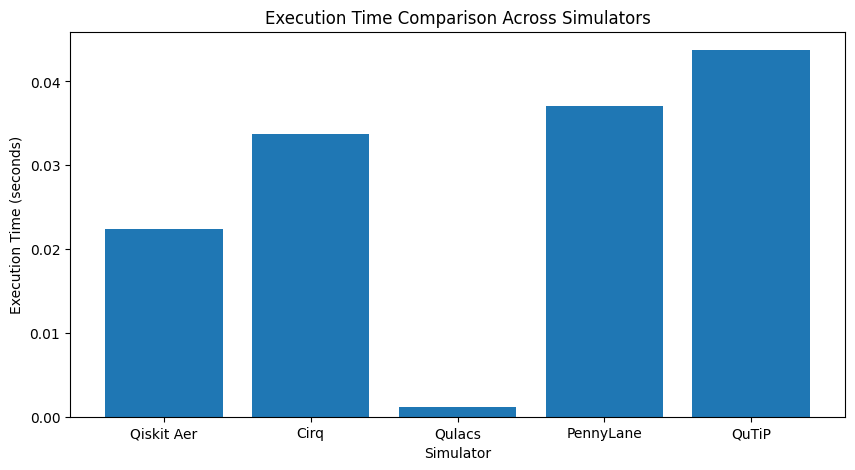

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Simulator"],
    results_df["Execution Time (s)"]
)

plt.title("Execution Time Comparison Across Simulators")
plt.xlabel("Simulator")
plt.ylabel("Execution Time (seconds)")

plt.show()

# Initial Observation

We have now run the same 10-qubit circuit with depth 5 on five different simulators.

This gives us our first comparison.

However, one circuit is not enough to understand scaling.

Next, we will increase the number of qubits and circuit depth to see how each simulator behaves as the circuit becomes larger.